# Digit Recognition using MNIST Dataset

## Horizon Internship Project

### Project Overview

This project develops a deep learning model to recognize handwritten digits using the MNIST dataset. A Convolutional Neural Network (CNN) is used to learn image patterns and accurately classify digits from 0 to 9.


## Objective

Develop a Convolutional Neural Network (CNN) that can accurately classify handwritten digits from the MNIST dataset.


## Import Libraries

Import the required Python libraries for data processing, visualization, deep learning, and model evaluation.


In [32]:
# Data Manipulation
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Model Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Dataset

Load the MNIST dataset provided by TensorFlow. The dataset contains grayscale images of handwritten digits along with their corresponding labels.


In [33]:
# Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


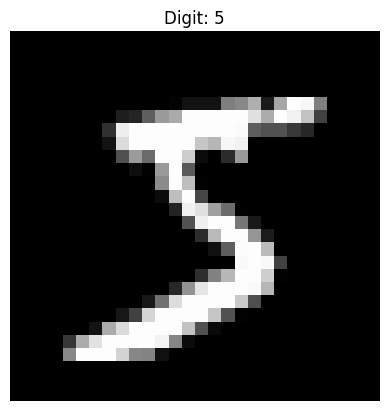

In [34]:
# Display the first image

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

## Dataset Overview

Explore the dataset to understand the number of training and testing samples, image dimensions, and label distribution.


In [35]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print()

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)

Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


In [36]:
print("Image Height :", X_train.shape[1])
print("Image Width :", X_train.shape[2])

Image Height : 28
Image Width : 28


In [37]:
print("Unique Classes :")

print(np.unique(y_train))

Unique Classes :
[0 1 2 3 4 5 6 7 8 9]


In [38]:
print("Number of Classes :", len(np.unique(y_train)))

Number of Classes : 10


### Analysis

The MNIST dataset contains 60,000 training images and 10,000 testing images. Each image is 28 × 28 pixels and represents one handwritten digit ranging from 0 to 9.


## Data Preprocessing

Normalize the pixel values and reshape the images to prepare them for training the Convolutional Neural Network.


In [39]:
# Check pixel value range before normalization

print("Before Normalization")
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Before Normalization
Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [40]:
# Normalize pixel values

X_train = X_train / 255.0
X_test = X_test / 255.0

In [41]:
# Check pixel value range after normalization

print("After Normalization")
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

After Normalization
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [42]:
# Reshape images

X_train = X_train.reshape(60000,28,28,1)

X_test = X_test.reshape(10000,28,28,1)

In [43]:
print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [44]:
# One-Hot Encode Labels

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [45]:
print("Encoded Label Shape :", y_train.shape)

Encoded Label Shape : (60000, 10)


### Analysis

The pixel values were normalized from a range of **0–255** to **0–1**, which helps the CNN train more efficiently. The images were then reshaped to match the input format required by the model, and the labels were converted into one-hot encoded vectors for multi-class classification.


## Exploratory Data Analysis

Explore the dataset by displaying sample handwritten digit images and examining the distribution of digit classes.


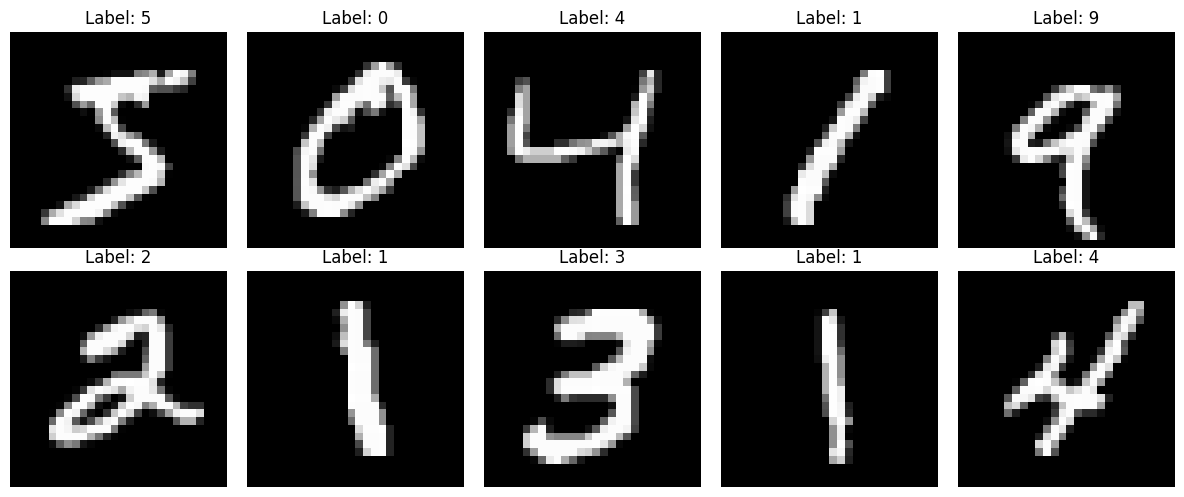

In [46]:
# Display the first 10 training images

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Analysis

The sample images show handwritten digits from 0 to 9 with different writing styles. These variations help the model learn meaningful patterns for accurate digit recognition.


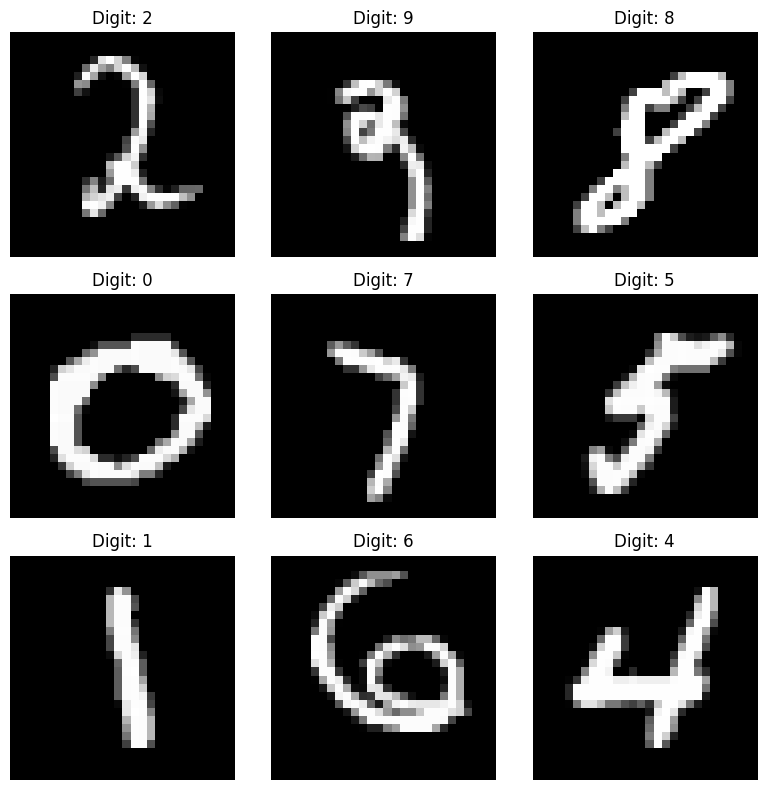

In [47]:
# Display 9 random images

plt.figure(figsize=(8,8))

random_images = np.random.randint(0, len(X_train), 9)

for i, index in enumerate(random_images):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[index].reshape(28,28), cmap='gray')
    plt.title(f"Digit: {np.argmax(y_train[index])}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Analysis

Random samples confirm that the dataset contains a variety of handwriting styles. This diversity improves the model's ability to generalize to unseen handwritten digits.


## Data Visualization

Visualize the distribution of digit classes to verify whether the dataset is balanced.


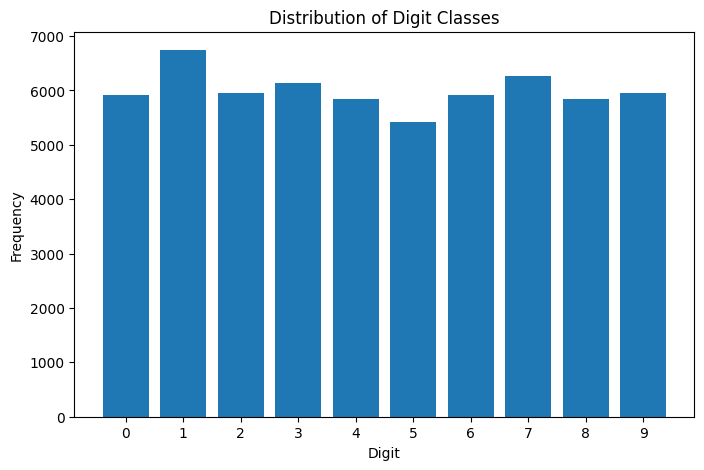

In [48]:
# Convert one-hot encoded labels back to class labels
digit_labels = np.argmax(y_train, axis=1)

plt.figure(figsize=(8,5))

plt.hist(digit_labels, bins=np.arange(11)-0.5, rwidth=0.8)

plt.xticks(range(10))

plt.title("Distribution of Digit Classes")
plt.xlabel("Digit")
plt.ylabel("Frequency")

plt.show()

### Analysis

The digit distribution shows that all classes are well represented in the training dataset. A balanced dataset helps the model learn each digit effectively without bias toward any specific class.


## Model Building

Build a Convolutional Neural Network (CNN) to extract image features and classify handwritten digits accurately.


In [49]:
# Build CNN Model

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

## Model Summary

Display the architecture of the Convolutional Neural Network, including each layer and the number of trainable parameters.


In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Analysis

The CNN architecture consists of convolutional, pooling, flatten, dense, and dropout layers. These layers work together to extract image features and improve classification performance while reducing overfitting.


## Compile the Model

Configure the optimizer, loss function, and evaluation metric before training the model.


In [51]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


## Model Training

Train the CNN model using the training dataset and validate its performance during each training epoch.


In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9343 - loss: 0.2162 - val_accuracy: 0.9812 - val_loss: 0.0652
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9800 - loss: 0.0680 - val_accuracy: 0.9866 - val_loss: 0.0485
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9843 - loss: 0.0503 - val_accuracy: 0.9873 - val_loss: 0.0444
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9885 - val_loss: 0.0419
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9897 - loss: 0.0315 - val_accuracy: 0.9897 - val_loss: 0.0364
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9915 - loss: 0.0269 - val_accuracy: 0.9904 - val_loss: 0.0346
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.9922 - loss: 0.0233 - val_accuracy: 0.9911 - val_loss: 0.0338
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9932 - loss: 0.0198 - val_accu

### Analysis

During training, the model learns meaningful features from handwritten digit images. The training and validation accuracy improve over successive epochs, indicating effective learning.


## Model Performance

Visualize the training and validation accuracy and loss to evaluate the learning performance of the CNN model.


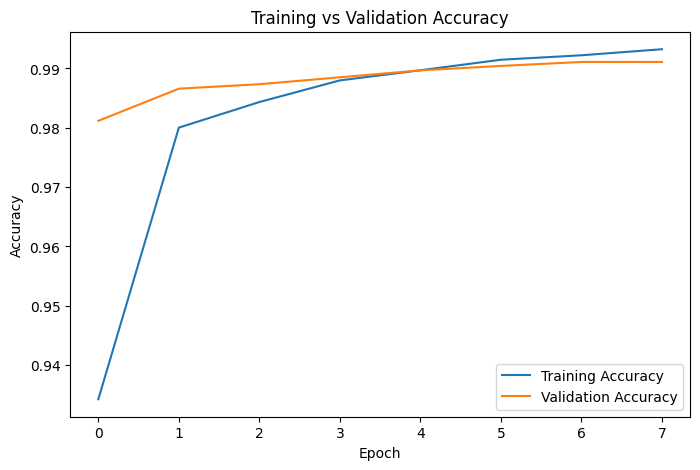

In [53]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Analysis

The training and validation accuracy increase steadily over the training epochs, indicating that the model is learning effectively and generalizing well to unseen data.


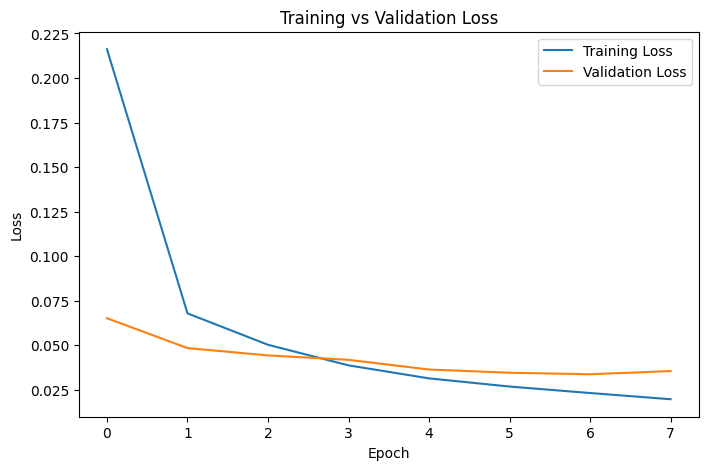

In [54]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Analysis

The training and validation loss decrease throughout the training process, showing that the model is improving its predictions while minimizing classification errors.


## Model Evaluation

Evaluate the trained CNN model using the testing dataset.


In [55]:
# Evaluate model

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy : {:.2f}%".format(test_accuracy*100))
print("Test Loss :", round(test_loss,4))

Test Accuracy : 99.15%
Test Loss : 0.0296


### Analysis

The model achieved high accuracy on the testing dataset, demonstrating its ability to correctly recognize handwritten digits and generalize well to new data.


## Prediction

Generate predictions for the testing dataset using the trained CNN model.


In [56]:
# Predict test images

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## Classification Report

Display precision, recall, and F1-score for each digit class.


In [57]:
print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Analysis

The classification report shows high precision, recall, and F1-score across all digit classes, indicating strong and consistent classification performance.


## Confusion Matrix

Visualize the model's prediction performance using a confusion matrix.


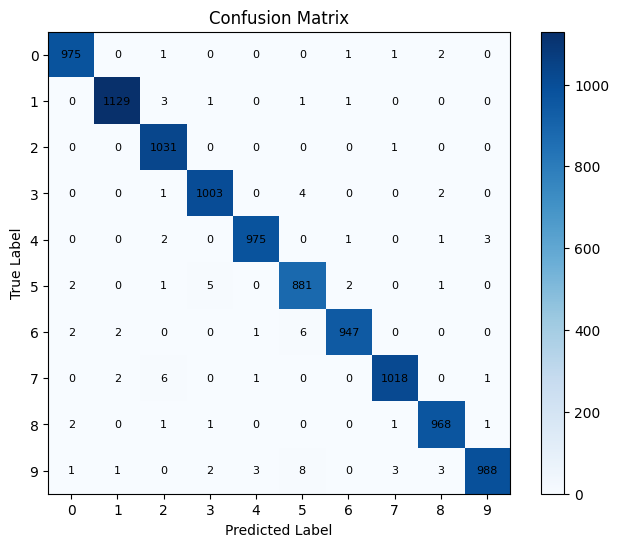

In [58]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Add values inside cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 fontsize=8)

plt.show()

### Analysis

The confusion matrix indicates that most handwritten digits were classified correctly. Misclassifications are minimal, demonstrating the effectiveness of the CNN model.


## Sample Predictions

Display a few testing images along with their actual and predicted labels.


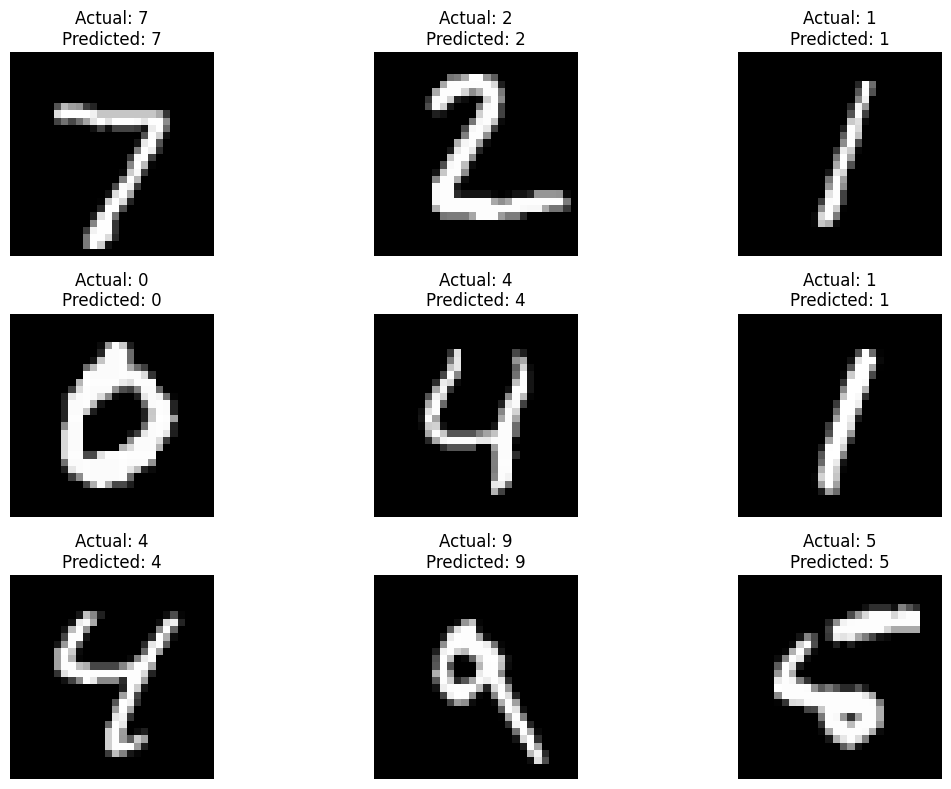

In [59]:
# Display sample predictions

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {true_labels[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Analysis

The sample predictions demonstrate that the model correctly recognizes handwritten digits, with predicted labels closely matching the actual labels.


# Conclusion

This project successfully developed a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset. After preprocessing the data, training the model, and evaluating its performance, the CNN achieved high accuracy on the testing dataset.

The results demonstrate the effectiveness of deep learning in image classification tasks and highlight the capability of CNNs to accurately recognize handwritten digits.


# Future Scope

* Improve performance through hyperparameter tuning.
* Apply data augmentation techniques to increase model robustness.
* Deploy the trained model as a web application using Flask or Streamlit.
* Extend the model to recognize handwritten characters and symbols.
